In [43]:
import pandas as pd
import numpy as np
import h5py
import json
import glob
import os
import sqlite3
import h5py
import matplotlib.pyplot as plt
from concurrent import futures
from itertools import repeat

In [44]:
mf = "/projects/vsokolov/hbw-austin"
expfolder="experiments"
output_dir_name = "Austin"
config = "scratch/config_morris_hbw.json"
metrics_file = f'{mf}/scratch/aus-mc-hbw.csv'

In [45]:
# Check if all are complete
for folder in  glob.glob(f'{mf}/{expfolder}/**'):
    if not os.path.isfile(f'{folder}/{output_dir_name}/finished'):
        print(f'{folder}/finished does not exist')

In [46]:
# EDA
def plotsum(f):
    sum = pd.read_csv(f'{f}/summary.csv', index_col=False)['in_network'].values
    with h5py.File(f'{f}/Austin-Result.h5', 'r') as f:
        # ref_output = f['link_moe']['link_travel_time'][:]*f['link_moe']['link_in_volume'][:]
        ref_output = f['link_moe']['num_vehicles_in_link'][:]
        ref_output =  np.sum(ref_output, axis=1)
    plt.close()
    fig, axs = plt.subplots(1,2,figsize=(6,2))
    axs[0].plot(sum)
    axs[1].plot(ref_output)

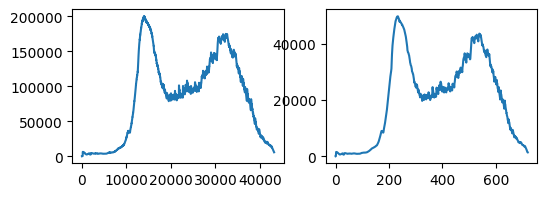

In [47]:
plotsum('/home/vsokolov/Austin/Austin_iteration_10/')

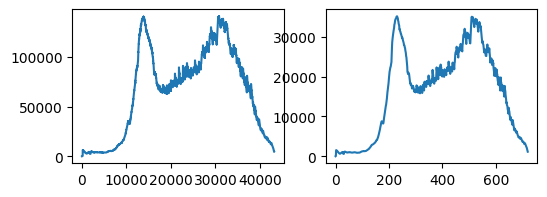

In [48]:
plotsum(f'../{expfolder}/Sim10/{output_dir_name}')

In [49]:
with open(f"{mf}/{config}",'r') as fh:
    config = json.load(fh)
polaris_json_file = list(config.keys())[0]
vars = [item['name'] for item in config[polaris_json_file]]
print(polaris_json_file)
print(vars)

control_files = glob.glob(f'{mf}/{expfolder}/**/{polaris_json_file}')
with open(control_files[0]) as fh:
    data = json.load(fh)
root_key = list(data.keys())[0]
root_key

CampoModeChoiceModel.json
['HBW_bCost_Generic', 'HBW_bCost_drive_Parking', 'HBW_bIVTT_drive', 'HBW_bIVTT_getRide', 'HBW_bIVTT_taxi', 'HBW_bIVTT_AcEgT_XitWlk', 'HBW_bInitWait_TransferTime_XitWlk', 'HBW_bIVTT_AcEgT_XitDrv', 'HBW_bInitWait_TransferTime_XitDrv', 'HBW_bIVTT_OVTTAcEg_Rail', 'HBW_bInitWait_TransferTime_Rail', 'HBW_bIVTT_OVTTAcEg_RailDrv', 'HBW_bInitWait_TransferTime_RailDrv', 'HBW_bTotalTime_Rail', 'HBW_bTotalTime_XitDrv']


'ADAPTS_Mode_Choice_Model'

In [50]:
d = []
for sim in control_files:    
    with open(sim) as fh:
        data = json.load(fh)
    vals = [data[root_key][item] for item in vars]
    vals= vals+[os.path.dirname(sim)]
    d.append(vals)

In [51]:
df = pd.DataFrame(d, columns=vars+['folder'])
df.iloc[0:3]
df.tail()
# df.to_csv('vals-folder.csv', index=False)

,HBW_bCost_Generic,HBW_bCost_drive_Parking,HBW_bIVTT_drive,HBW_bIVTT_getRide,HBW_bIVTT_taxi,HBW_bIVTT_AcEgT_XitWlk,HBW_bInitWait_TransferTime_XitWlk,HBW_bIVTT_AcEgT_XitDrv,HBW_bInitWait_TransferTime_XitDrv,HBW_bIVTT_OVTTAcEg_Rail,HBW_bInitWait_TransferTime_Rail,HBW_bIVTT_OVTTAcEg_RailDrv,HBW_bInitWait_TransferTime_RailDrv,HBW_bTotalTime_Rail,HBW_bTotalTime_XitDrv,folder
123,-5.360000,-0.010,-0.092933,-0.0100,-0.494,-0.359778,-0.125600,-0.048533,-0.2512,-0.010000,-0.1488,-0.010000,-0.148800,-0.010000,-0.0976,/projects/vsokolov/hbw-austin/experiments/Sim95
124,-3.576667,-0.010,-0.092933,-0.2436,-0.494,-0.359778,-0.048533,-0.087067,-0.1708,-0.052933,-0.0100,-0.031467,-0.148800,-0.052933,-0.0392,/projects/vsokolov/hbw-austin/experiments/Sim96
125,-3.576667,-2.086,-0.092933,-0.2436,-0.494,-0.359778,-0.048533,-0.087067,-0.1708,-0.052933,-0.0100,-0.031467,-0.148800,-0.052933,-0.0392,/projects/vsokolov/hbw-austin/experiments/Sim97
126,-3.576667,-2.086,-0.092933,-0.2436,-0.494,-0.359778,-0.048533,-0.087067,-0.1708,-0.010000,-0.0100,-0.031467,-0.148800,-0.052933,-0.0392,/projects/vsokolov/hbw-austin/experiments/Sim98
127,-3.576667,-2.086,-0.092933,-0.2436,-0.494,-0.359778,-0.048533,-0.087067,-0.1708,-0.010000,-0.0100,-0.031467,-0.056267,-0.052933,-0.0392,/projects/vsokolov/hbw-austin/experiments/Sim99


In [52]:
def get_diurnal_mode(i):
    f = df.loc[i,'folder']
    con = sqlite3.connect(f"{f}/{output_dir_name}/Austin-Demand.sqlite")
    trip = pd.read_sql_query("SELECT start,mode from trip", con)
    bins= np.arange(0, 60*60*24, 20*60)
    groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
    groups.size().unstack().transpose().to_csv(f"../scratch/diurnal-mode/{f.split('/')[-1]}-dm.csv", index=False)
    return f
# get_diurnal_mode(0)

In [53]:
with futures.ThreadPoolExecutor(10) as executor:
    result = executor.map(get_diurnal_mode, range(len(df)))
    for res in result:
        print(res)

/scratch/vsokolov/tmp/ipykernel_13169/293935108.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
/scratch/vsokolov/tmp/ipykernel_13169/293935108.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
/scratch/vsokolov/tmp/ipykernel_13169/293935108.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups =

/projects/vsokolov/hbw-austin/experiments/Sim0


/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])


/projects/vsokolov/hbw-austin/experiments/Sim1


/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])


/projects/vsokolov/hbw-austin/experiments/Sim10


/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
/scratch/vsokolov/tmp/ipykernel_13169/310701970.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups =

/projects/vsokolov/hbw-austin/experiments/Sim100
/projects/vsokolov/hbw-austin/experiments/Sim101
/projects/vsokolov/hbw-austin/experiments/Sim102
/projects/vsokolov/hbw-austin/experiments/Sim103
/projects/vsokolov/hbw-austin/experiments/Sim104
/projects/vsokolov/hbw-austin/experiments/Sim105
/projects/vsokolov/hbw-austin/experiments/Sim106


In [ ]:
f = df.loc[0,'folder']
con = sqlite3.connect(f"{f}/{output_dir_name}/Austin-Demand.sqlite")
res = con.execute("select mode, count(*) from Trip group by mode").fetchall()
mode, share = ([i for i, j in res],[j for i, j in res])
print(mode,share)
for i in mode:
    df[f'm{i}'] = 0
df.head()
df.tail()

In [ ]:
def get_demand(i):
    f = df.loc[i,'folder']
    with open(f'{f}/{output_dir_name}/log/polaris_progress.log','r') as fh:
        if fh.readlines() [-3:][0].find('Finished') == -1:
            return(False, f"{f} is not finished, skipping")
    con = sqlite3.connect(f"{f}/{output_dir_name}/Austin-Demand.sqlite")
    res = con.execute("select mode, count(*) from Trip group by mode").fetchall()
    mode, share = ([i for i, j in res],[j for i, j in res])
    for j in range(len(mode)):
        df.loc[i,f'm{mode[j]}'] = share[j]#/sum(share)
    return(True, f"{f} {share[0]}")

In [ ]:
with futures.ThreadPoolExecutor(20) as executor:
    result = executor.map(get_demand, range(len(df)))
    for res in result:
        flag, msg = res
        if not flag:
            print(msg)

In [ ]:
(df['m0']/df['m0'].sum()).plot()

In [ ]:
df['net'] = 0.0
df.head()

In [ ]:
def get_network_metrics(db):
    with h5py.File(db, 'r') as f:
        # ref_output = f['link_moe']['link_travel_time'][:]*f['link_moe']['link_in_volume'][:]
        res = f['link_moe']['num_vehicles_in_link'][:]
        res =  np.sum(res, axis=1)
    return res
def get_network(i,refout):
    f = df.loc[i,'folder']
    db = f'{f}/{output_dir_name}/Austin-Result.h5'
    out = get_network_metrics(db)
    res = np.mean(np.abs(out-refout))
    df.loc[i,'net'] = res
    # print(f"{f} {res}")
    return(res)

In [ ]:
refout = get_network_metrics("/home/vsokolov/Austin/Austin_iteration_10/Austin-Result.h5")
plt.plot(refout)

In [ ]:
get_network(0,refout)
df.head()

In [ ]:
with futures.ThreadPoolExecutor(10) as executor:
    result = executor.map(get_network, range(len(df)),repeat(refout))
    for res in result:
        print(res)  

In [ ]:
df.head()
df.to_csv(metrics_file, index=False)